# Figure 2
## Enrichment of PCG around ncRNA's TSS
### Author: Martin Loza
### Date: 25/12/05

In this Figure we explore the enrichment of protein coding gene around the TSS of ncRNA.

In [46]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
})

# Local variables
seed = 777
date = "251205"

in_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENSEMBL/selected/"
out_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Figure_2/Plots/"

### Load and setup the data

In [47]:
# Load the setup transcripts data
# We have different species, so let's create a list to store the data
data_list = list()

# Search for the available files
files <- list.files(in_dir)

# Load the data for each species
for (file in files) {
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(file, "_.*", "")
    data_list[[species_name]] <- read.table(file.path(in_dir, file), sep = "\t", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL)
}

head(data_list[["dog"]], 3)


,row.names,Chromosome.scaffold.name,Gene.start..bp.,Gene.end..bp.,Strand,Gene.stable.ID,Transcript.stable.ID,Transcript.start..bp.,Transcript.end..bp.,Transcript.type,Gene.type,Gene.name,Gene.description,TSS,is_pcg,is_ncrna
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,1,48283,118098,-1,ENSCAFG00845000008,ENSCAFT00845000010,48283,118098,protein_coding,protein_coding,ENPP1,ectonucleotide pyrophosphatase/phosphodiesterase 1 [Source:UniProtKB Gene Name;Acc:A0A8I3RQK2],118098,TRUE,FALSE
2,2,1,48283,118098,-1,ENSCAFG00845000008,ENSCAFT00845000011,49956,118098,protein_coding,protein_coding,ENPP1,ectonucleotide pyrophosphatase/phosphodiesterase 1 [Source:UniProtKB Gene Name;Acc:A0A8I3RQK2],118098,TRUE,FALSE
3,3,1,48283,118098,-1,ENSCAFG00845000008,ENSCAFT00845000016,49956,118098,protein_coding,protein_coding,ENPP1,ectonucleotide pyrophosphatase/phosphodiesterase 1 [Source:UniProtKB Gene Name;Acc:A0A8I3RQK2],118098,TRUE,FALSE


Let's focus on ncRNA and protein coding genes. 
We already classify them and labeled them usin the columns is_pcg and is_ncrna.

Let's also set TSS as integer.

In [48]:
# Setup the data
data_list_selected <- lapply(data_list, function(x){
    # Select only PCGs and ncRNAs
    x <- x %>% filter(is_pcg == TRUE | is_ncrna == TRUE)
    # Set TSS as integer
    x$TSS <- as.integer(x$TSS)
    # Set Strand as character
    x$Strand <- as.character(x$Strand)
    return(x)
})


In [49]:
# Example in mouse annotations
cat("Is_PCG:\n")
table(data_list_selected[["mouse"]]$is_pcg)
cat("Is_ncrna:\n")
table(data_list_selected[["mouse"]]$is_ncrna)

Is_PCG:



 FALSE   TRUE 
158258  58697 

Is_ncrna:



 FALSE   TRUE 
 58697 158258 

### Figure

In [64]:
# Function to visualize the enrichment of PCG's TSS near ncRNA's TSS
plot_pcg_ncrna_distribution <- function(data, window_size = 10000, bin_width = 50, 
                                        species_name = "Species") {
    # Filter PCG and ncRNA
    pcg_data <- data %>% filter(is_pcg == TRUE)
    ncrna_data <- data %>% filter(is_ncrna == TRUE)
    
    # Calculate distances from each PCG to all ncRNA on the same chromosome
    distance_data <- list()
    
    for (i in 1:nrow(ncrna_data)) {
        # Get ncRNA info
        ncrna_chr <- ncrna_data$Chromosome.scaffold.name[i]
        ncrna_tss <- ncrna_data$TSS[i]
        
        # Find PCGs on the same chromosome
        pcg_same_chr <- pcg_data %>% 
            filter(Chromosome.scaffold.name == ncrna_chr)

        if (nrow(pcg_same_chr) > 0) {
            # Calculate distances (PCG TSS - ncRNA TSS)
            distances <- pcg_same_chr$TSS - ncrna_tss
            
            # Filter by window size
            in_window <- abs(distances) <= window_size
            
            if (sum(in_window) > 0) {
                distance_data[[length(distance_data) + 1]] <- data.frame(
                    distance = distances[in_window],
                    strand = pcg_same_chr$Strand[in_window]
                )
            }
        }
    }
    
    # Combine all distances
    if (length(distance_data) > 0) {
        all_distances <- do.call(rbind, distance_data)
        
        # Convert strand to factor for plotting
        all_distances$strand <- factor(all_distances$strand, 
                                       levels = c(1, -1),
                                       labels = c("Forward (+1)", "Reverse (-1)"))
        
        # Create the plot
        p <- ggplot(all_distances, aes(x = distance, fill = strand)) +
            geom_histogram(position  = "dodge", alpha = 0.6,bins = bin_width) +
            scale_fill_manual(values = c("Forward (+1)" = "#E41A1C", 
                                        "Reverse (-1)" = "#377EB8")) +
            # geom_vline(xintercept = 0, linetype = "dashed", color = "black", size = ) +
            labs(
                title = paste("Distribution of PCG TSS around ncRNA TSS -", species_name),
                x = "Distance from ncRNA TSS (bp)",
                y = "Count of PCG",
                fill = "PCG Strand"
            ) +
            theme_classic() +
            theme(
                plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
                axis.text = element_text(size = 11),
                axis.title = element_text(size = 12, face = "bold"),
                legend.position = "top",
                legend.title = element_text(face = "bold")
            )
        
        return(p)
    } else {
        warning("No PCG found within the specified window around ncRNA TSS")
        return(NULL)
    }
}


In [41]:
is(data_list_selected[["human"]]$TSS[1])

[1] "integer"             "double"              "numeric"            
[4] "vector"              "data.frameRowLabels"

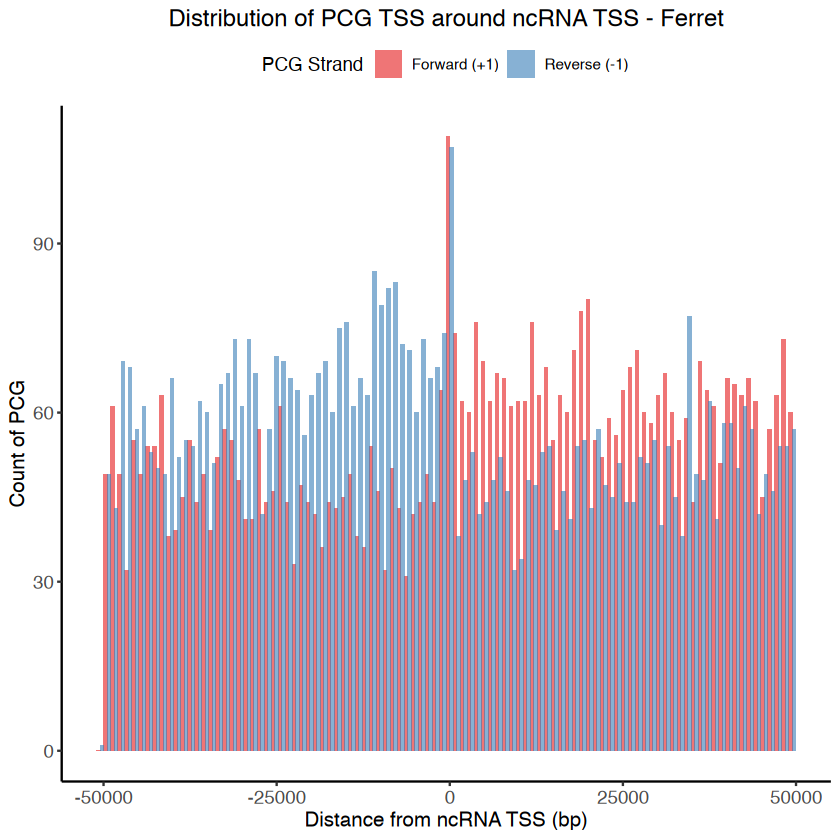

In [66]:
# Test the function with human data
p <- plot_pcg_ncrna_distribution(data_list_selected[["ferret"]], 
                                          window_size = 50000, 
                                          bin_width = 100,
                                          species_name = "Ferret")
print(p)